In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import geopandas as gpd
import os
import rasterio
import contextily as cx
import pyproj
import requests
import json

from shapely.geometry import Point
from pathlib import Path
from pyproj import Transformer
from shapely.geometry import Point, LineString

from pathlib import Path
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

from rasterio.vrt import WarpedVRT
from rasterio.windows import from_bounds
from rasterio.enums import Resampling
from matplotlib.colors import LightSource
from rasterio.merge import merge
from rasterio.transform import array_bounds

In [3]:
gravity_path = "../../data/gravity/raw_data/gps_data/gravity_05_27_2026.csv"
poi_path = "../../data/GPR/raw_data/GPS_Emlid/group2_onyx_mine.csv"

gravity_df = pd.read_csv(gravity_path)
poi_df = pd.read_csv(poi_path)

gravity_gps = gravity_df[["Name", "Longitude", "Latitude", "Ellipsoidal height"]].copy()
gravity_gps = gravity_gps.rename(columns={
    "Name": "station",
    "Ellipsoidal height": "elevation_m"
})

poi_gps = poi_df[["Name", "Longitude", "Latitude", "Elevation", "Ellipsoidal height"]].copy()
poi_gps = poi_gps.rename(columns={
    "Name": "point_name",
    "Elevation": "elevation_m",
    "Ellipsoidal height": "ellipsoidal_height_m"
})

gravity_gdf = gpd.GeoDataFrame(
    gravity_gps,
    geometry=gpd.points_from_xy(gravity_gps["Longitude"], gravity_gps["Latitude"]),
    crs="EPSG:4326"
)

poi_gdf = gpd.GeoDataFrame(
    poi_gps,
    geometry=gpd.points_from_xy(poi_gps["Longitude"], poi_gps["Latitude"]),
    crs="EPSG:4326"
)

In [4]:
gpr_folder_gopher = Path("../../data/GPR/raw_data/Gopher/")
gpr_folder_moose = Path("../../data/GPR/raw_data/Moose/")

gps_extensions = [".csv", ".txt", ".gps", ".gpx", ".kml", ".cor", ".xyz"]

gpr_gps_candidates = []

for folder in [gpr_folder_gopher, gpr_folder_moose]:
    for file in folder.rglob("*"):
        if file.is_file() and file.suffix.lower() in gps_extensions:
            gpr_gps_candidates.append(file)

print("Possible GPR GPS files found:", len(gpr_gps_candidates))
for file in gpr_gps_candidates:
    print(file)

Possible GPR GPS files found: 12
../../data/GPR/raw_data/Gopher/GPR_group2_2026_05_25_gopher_2026-05-25_0004.cor
../../data/GPR/raw_data/Gopher/GPR_group2_2026_05_25_gopher_2026-05-25_0001.cor
../../data/GPR/raw_data/Gopher/GPR_group2_2026_05_25_gopher_2026-05-25_0003.cor
../../data/GPR/raw_data/Gopher/GPR_group2_2026_05_25_gopher_2026-05-25_0002.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0008.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0004.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0005.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0007.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0006.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0002.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0003.cor
../../data/GPR/raw_data/Moose/GPR_group2_2026_05_21_2026-05-25_0001.cor


In [5]:
gpr_dfs = []

for file in gpr_gps_candidates:
    temp = pd.read_csv(
        file,
        sep="\t",
        header=None,
        names=[
            "trace",
            "date",
            "time",
            "latitude",
            "lat_dir",
            "longitude",
            "lon_dir",
            "elevation_m",
            "elevation_unit",
            "quality"
        ]
    )
    
    temp["source_file"] = file.name
    
    if "gopher" in str(file).lower():
        temp["gpr_device"] = "Gopher"
    else:
        temp["gpr_device"] = "Moose"
    
    temp["line_name"] = file.stem
    gpr_dfs.append(temp)

gpr_df = pd.concat(gpr_dfs, ignore_index=True)

gpr_df["latitude"] = pd.to_numeric(gpr_df["latitude"], errors="coerce")
gpr_df["longitude"] = pd.to_numeric(gpr_df["longitude"], errors="coerce")
gpr_df["elevation_m"] = pd.to_numeric(gpr_df["elevation_m"], errors="coerce")

gpr_df.loc[gpr_df["lat_dir"].str.upper() == "S", "latitude"] *= -1
gpr_df.loc[gpr_df["lon_dir"].str.upper() == "W", "longitude"] *= -1

gpr_df = gpr_df.dropna(subset=["latitude", "longitude"]).copy()

gpr_points_gdf = gpd.GeoDataFrame(
    gpr_df,
    geometry=gpd.points_from_xy(gpr_df["longitude"], gpr_df["latitude"]),
    crs="EPSG:4326"
)

gpr_lines = []

for line_name, group in gpr_points_gdf.groupby("line_name"):
    group = group.sort_values("trace")
    
    if len(group) >= 2:
        gpr_lines.append({
            "line_name": line_name,
            "gpr_device": group["gpr_device"].iloc[0],
            "n_points": len(group),
            "geometry": LineString(group.geometry.tolist())
        })

gpr_lines_gdf = gpd.GeoDataFrame(gpr_lines, crs="EPSG:4326")

display(gpr_lines_gdf[["line_name", "gpr_device", "n_points"]])

/var/folders/lx/bjmg_9nd62z3tvrszw3rrpw00000gn/T/ipykernel_19624/4053105417.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gpr_df = pd.concat(gpr_dfs, ignore_index=True)


,line_name,gpr_device,n_points
0,GPR_group2_2026_05_21_2026-05-25_0001,Moose,8
1,GPR_group2_2026_05_21_2026-05-25_0002,Moose,162
2,GPR_group2_2026_05_21_2026-05-25_0003,Moose,138
3,GPR_group2_2026_05_21_2026-05-25_0004,Moose,460
4,GPR_group2_2026_05_21_2026-05-25_0005,Moose,466
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
7,GPR_group2_2026_05_25_gopher_2026-05-25_0001,Gopher,5
8,GPR_group2_2026_05_25_gopher_2026-05-25_0002,Gopher,2
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113


In [6]:
gravity_3857 = gravity_gdf.to_crs(epsg=3857)
poi_3857 = poi_gdf.to_crs(epsg=3857)
gpr_lines_3857 = gpr_lines_gdf.to_crs(epsg=3857)
gpr_points_3857 = gpr_points_gdf.to_crs(epsg=3857)

In [7]:
selected_gpr_lines = gpr_lines_3857[
    (
        (gpr_lines_3857["gpr_device"] == "Gopher") &
        (gpr_lines_3857["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_3857["gpr_device"] == "Moose") &
        (gpr_lines_3857["line_name"].str.endswith(("0007", "0008")))
    )
].copy()

display(selected_gpr_lines[["line_name", "gpr_device", "n_points"]])

,line_name,gpr_device,n_points
5,GPR_group2_2026_05_21_2026-05-25_0007,Moose,121
6,GPR_group2_2026_05_21_2026-05-25_0008,Moose,98
9,GPR_group2_2026_05_25_gopher_2026-05-25_0003,Gopher,113
10,GPR_group2_2026_05_25_gopher_2026-05-25_0004,Gopher,65


In [8]:
anomaly_df = pd.DataFrame({
    "anomaly_id": [
        "G03-A", "G03-B", "G03-C",
        "G04-A", "G04-B",
        "M07-A",
        "M08-A", "M08-B"
    ],

    "line": [
        "Gopher 03", "Gopher 03", "Gopher 03",
        "Gopher 04", "Gopher 04",
        "Moose 07",
        "Moose 08", "Moose 08"
    ],

    "frequency_MHz": [
        600, 600, 600,
        600, 600,
        300,
        300, 300
    ],

    "easting": [
        344405.8, 344414.1, 344421.0,
        344417.2, 344414.2,
        344422.0,
        344404.5, 344414.0
    ],

    "northing": [
        4482540.1, 4482521.8, 4482499.8,
        4482507.0, 4482520.6,
        4482496.4,
        4482538.4, 4482517.1
    ],

    "twt_ns": [
        28.8, 15.8, 14.6,
        36.4, 23.9,
        128.3,
        40.8, 22.8
    ]
})

In [9]:
velocity = 0.10  # m/ns

anomaly_df["depth_m"] = (
    anomaly_df["twt_ns"] * velocity / 2
)

In [10]:
anomaly_gdf = gpd.GeoDataFrame(
    anomaly_df,
    geometry=gpd.points_from_xy(anomaly_df["easting"], anomaly_df["northing"]),
    crs="EPSG:32613"
)

anomaly_3857 = anomaly_gdf.to_crs(epsg=3857)

anomaly_3857[["anomaly_id", "line", "frequency_MHz", "twt_ns", "depth_m", "geometry"]]

,anomaly_id,line,frequency_MHz,twt_ns,depth_m,geometry
0,G03-A,Gopher 03,600,28.8,1.440,POINT (-11892889.795 4935792.762)
1,G03-B,Gopher 03,600,15.8,0.790,POINT (-11892878.4 4935768.874)
2,G03-C,Gopher 03,600,14.6,0.730,POINT (-11892868.742 4935740.072)
3,G04-A,Gopher 04,600,36.4,1.820,POINT (-11892873.927 4935749.456)
4,G04-B,Gopher 04,600,23.9,1.195,POINT (-11892878.236 4935767.296)
5,M07-A,Moose 07,300,128.3,6.415,POINT (-11892867.337 4935735.619)
6,M08-A,Moose 08,300,40.8,2.040,POINT (-11892891.455 4935790.487)
7,M08-B,Moose 08,300,22.8,1.140,POINT (-11892878.403 4935762.678)


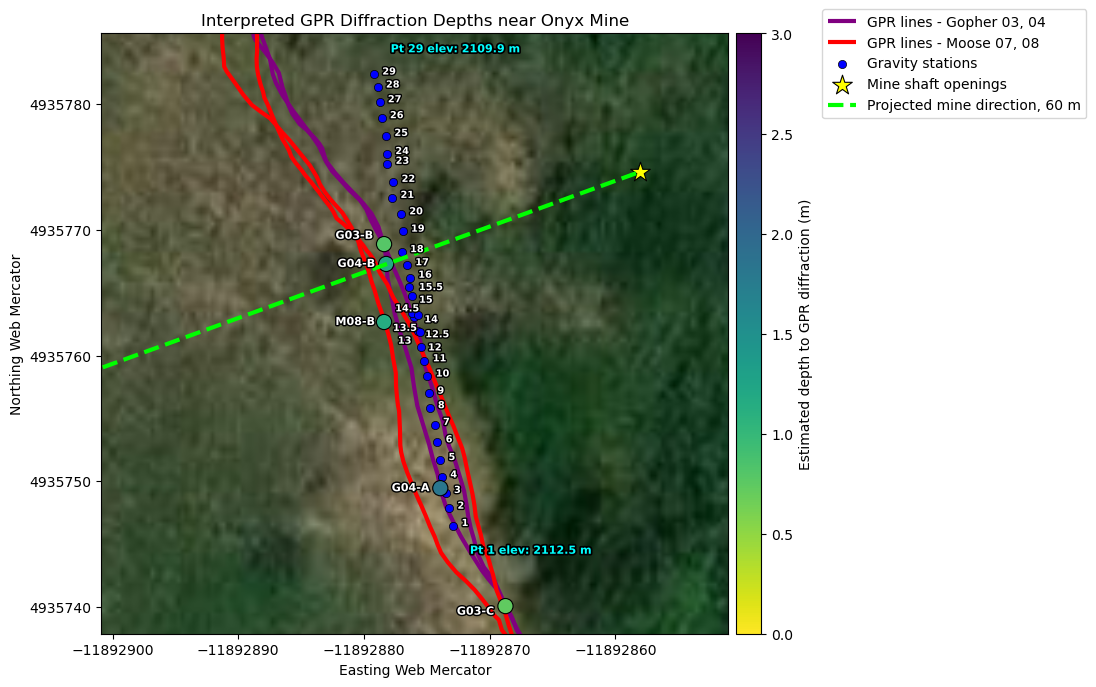

In [11]:
figsize = (10, 20)
buffer = -5

zoom_vmin = 0.0
zoom_vmax = 3.0

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

gravity_marker_size = 35
poi_marker_size = 220
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")

elevation_label_offsets = {
    1:  (12, -18, "left", "center"),
    29: (12, 18, "left", "center"),
}

anomaly_label_offsets = {
    "G03-A": (10, 0, "left", "center"),
    "G03-B": (10, 6, "left", "center"),
    "G03-C": (10, -4, "left", "center"),
    "G04-A": (10, 0, "left", "center"),
    "G04-B": (10, 0, "left", "center"),
    "M07-B": (10, 0, "left", "center"),
    "M08-B": (10, 0, "left", "center"),
}

default_anomaly_label_offset = (10, 0, "left", "center")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)

        if value.is_integer():
            return str(int(value)), int(value)

        return str(value).rstrip("0").rstrip("."), value

    except Exception:
        return str(value), value


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_3857,
    ["station_num", "station", "Name"],
    "Could not find gravity station column. Check gravity_3857.columns."
)

elevation_col = find_col(
    gravity_3857,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column. Check gravity_3857.columns."
)

poi_name_col = find_col(
    poi_3857,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_3857.columns."
)


# ============================================================
# Prep gravity station numbers
# ============================================================

gravity_3857 = gravity_3857.copy()

gravity_3857["station_num_clean"] = pd.to_numeric(
    gravity_3857[gravity_station_col],
    errors="coerce"
)


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_3857[
    poi_3857[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_3857[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_m * np.sin(azimuth_rad)
dy = mine_projection_length_m * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_3857.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_3857.crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_3857[["geometry"]],
    poi_3857[["geometry"]],
    selected_gpr_lines[["geometry"]],
    anomaly_3857[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - 2.7*buffer, xmax + -1.4*buffer)
ax.set_ylim(ymin - 1.6 * buffer, ymax + 4 * buffer)


# ============================================================
# Basemap
# ============================================================

cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldImagery,
    zoom=19,
    attribution=False
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines[selected_gpr_lines["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations
# ============================================================

gravity_3857.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)


# ============================================================
# Plot mine shaft openings
# ============================================================

poi_3857.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ============================================================
# Plot GPR diffraction anomalies with fixed colorbar
# ============================================================

divider = make_axes_locatable(ax)

cax = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

anomaly_3857.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    vmin=zoom_vmin,
    vmax=zoom_vmax,
    markersize=anomaly_marker_size,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    cax=cax,
    legend_kwds={
        "label": "Estimated depth to GPR diffraction (m)",
        "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3]
    },
    zorder=6
)


# ============================================================
# Label gravity stations
# ============================================================

for _, row in gravity_3857.iterrows():
    display_label, lookup_label = clean_label(row[gravity_station_col])

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=gravity_label_size,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Label elevations at gravity points 1 and 29 only
# ============================================================

elevation_points = gravity_3857[
    gravity_3857["station_num_clean"].isin([1, 29])
].copy()

for _, row in elevation_points.iterrows():
    station = int(row["station_num_clean"])
    elevation = float(row[elevation_col])

    x_offset, y_offset, ha, va = elevation_label_offsets.get(
        station,
        (12, 12, "left", "center")
    )

    ax.annotate(
        f"Pt {station} elev: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=elevation_label_size,
        color="cyan",
        weight="bold",
        ha=ha,
        va=va,
        zorder=12,
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground="black")
        ]
    )


# ============================================================
# Label GPR anomalies
# ============================================================

for _, row in anomaly_3857.iterrows():
    anomaly_id = row["anomaly_id"]

    x_offset, y_offset, ha, va = anomaly_label_offsets.get(
        anomaly_id,
        default_anomaly_label_offset
    )

    ax.annotate(
        anomaly_id,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset - 45, y_offset),
        textcoords="offset points",
        fontsize=anomaly_label_size,
        weight="bold",
        color="white",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Final formatting
# ============================================================

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine")
ax.set_xlabel("Easting Web Mercator")
ax.set_ylabel("Northing Web Mercator")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.15, 1.04),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.76,
    bottom=0.12,
    top=0.92
)

plt.show()

In [12]:
lidar_path = "../../data/LiDAR/LiDAR_2026-06-05T15_32_32.740Z/"

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T15_32_32.740Z")

lidar_files = sorted(lidar_folder.glob("*.tif"))

print("LiDAR files found:")
for f in lidar_files:
    print(f)

LiDAR files found:


In [13]:

if len(lidar_files) == 0:
    lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
    lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError("No .tif LiDAR files found. Check your lidar_folder path.")

print(f"Found {len(lidar_files)} LiDAR files:")
for f in lidar_files:
    print(f)

Found 21 LiDAR files:
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171427.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201427.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26261415.tif
../../data/LiDAR/LiDAR_2026-06-05

In [14]:
for fp in lidar_files:
    with rasterio.open(fp) as src:
        print("\nFILE:", fp.name)
        print("CRS:", src.crs)
        print("Bounds:", src.bounds)
        print("Nodata:", src.nodata)
        print("Units maybe:", src.crs.linear_units if src.crs else "unknown")


FILE: LD26171415.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2617000.0, bottom=1415000.0, right=2620000.0, top=1418000.0)
Nodata: -9999.0
Units maybe: US survey foot

FILE: LD26171418.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2617000.0, bottom=1418000.0, right=2620000.0, top=1421000.0)
Nodata: -9999.0
Units maybe: US survey foot

FILE: LD26171421.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2617000.0, bottom=1421000.0, right=2620000.0, top=1424000.0)
Nodata: -9999.0
Units maybe: US survey foot

FILE: LD26171424.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2617000.0, bottom=1424000.0, right=2620000.0, top=1427000.0)
Nodata: -9999.0
Units maybe: US survey foot

FILE: LD26171427.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2617000.0, bottom=1427000.0, right=2620000.0, top=1430000.0)
Nodata: -9999.0
Units maybe: US survey foot

FILE: LD26201415.tif
CRS: EPSG:6430
Bounds: BoundingBox(left=2620000.0, bottom=1415000.0, right=2623000.0, top=1418000.0)
Nodata: -9999.0
Units maybe: US survey foo

LiDAR files being used:
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171427.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201427.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26261415.tif
../../data/LiDAR/LiDAR_2026-06-

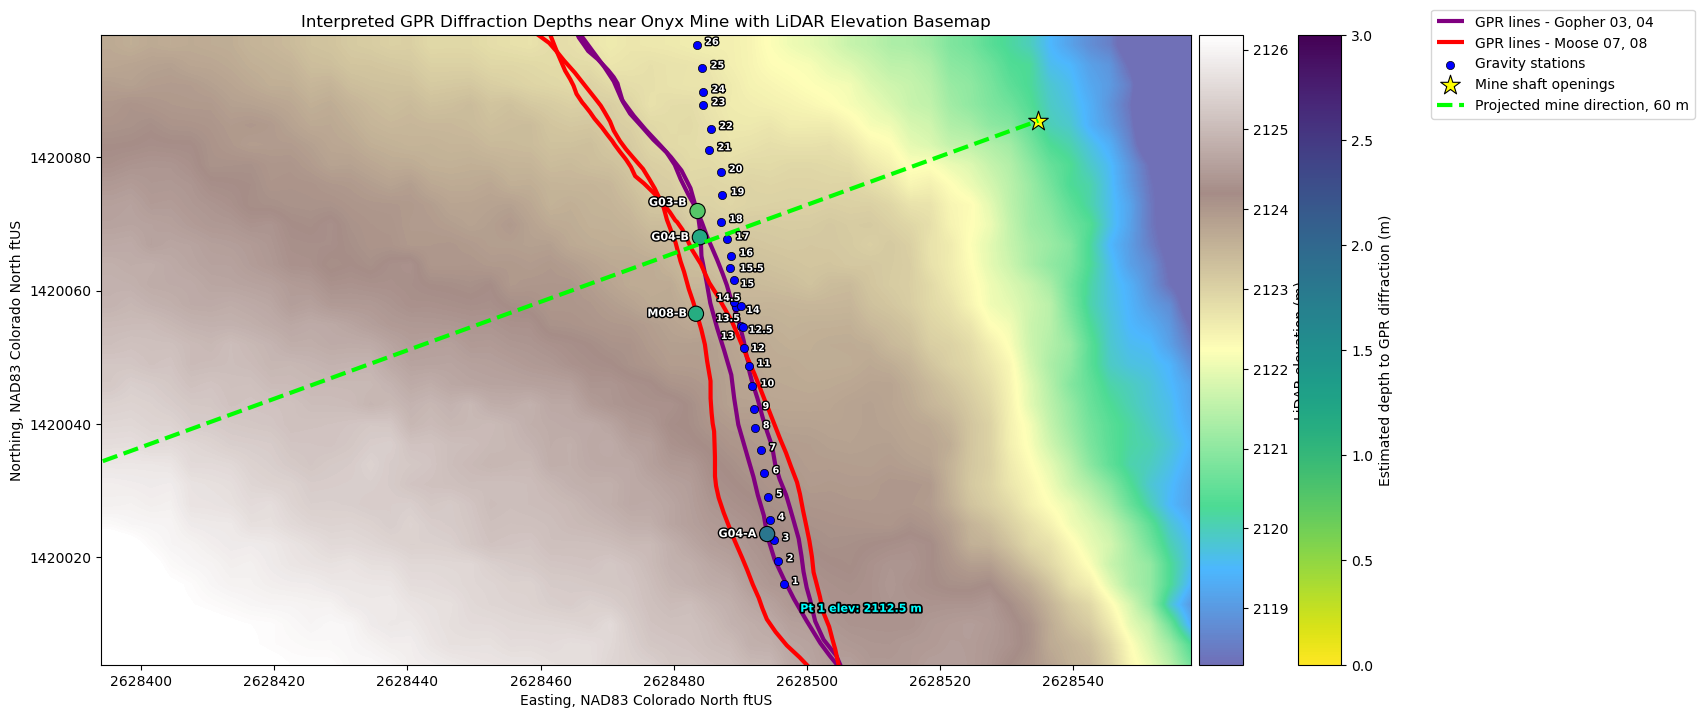

In [17]:
figsize = (20, 35)

# Your LiDAR CRS is Colorado North ftUS, so map coordinates are feet.
# These values are written in meters and converted below.
buffer_m = -5

zoom_vmin = 0.0
zoom_vmax = 3.0

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

gravity_marker_size = 35
poi_marker_size = 220
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8

lidar_alpha = 0.70
lidar_cmap = "terrain"

# LiDAR horizontal CRS is ftUS.
# Elevation values are probably also feet unless metadata says otherwise.
lidar_z_units = "ft"   # use "ft", "in", or "m"

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")

elevation_label_offsets = {
    1:  (12, -18, "left", "center"),
    29: (12, 18, "left", "center"),
}

anomaly_label_offsets = {
    "G03-A": (10, 0, "left", "center"),
    "G03-B": (10, 6, "left", "center"),
    "G03-C": (10, -4, "left", "center"),
    "G04-A": (10, 0, "left", "center"),
    "G04-B": (10, 0, "left", "center"),
    "M07-A": (10, 0, "left", "center"),
    "M08-A": (10, 0, "left", "center"),
    "M08-B": (10, 0, "left", "center"),
}

default_anomaly_label_offset = (10, 0, "left", "center")


# ============================================================
# Unit conversions
# ============================================================

ftus_per_m = 1 / 0.304800609601219
buffer = buffer_m * ftus_per_m
mine_projection_length_map_units = mine_projection_length_m * ftus_per_m

z_to_m = {
    "m": 1.0,
    "ft": 0.3048,
    "in": 0.0254
}

if lidar_z_units not in z_to_m:
    raise ValueError("lidar_z_units must be 'm', 'ft', or 'in'.")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)

        if value.is_integer():
            return str(int(value)), int(value)

        return str(value).rstrip("0").rstrip("."), value

    except Exception:
        return str(value), value


# ============================================================
# Load LiDAR files and CRS
# ============================================================

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError(f"No LiDAR .tif files found in: {lidar_folder}")

print("LiDAR files being used:")
for f in lidar_files:
    print(f)

with rasterio.open(lidar_files[0]) as src:
    lidar_crs = src.crs

print("\nPlotting all survey data in LiDAR CRS:")
print(lidar_crs)


# ============================================================
# Reproject survey layers into LiDAR CRS
# ============================================================

gravity_plot = gravity_gdf.to_crs(lidar_crs)
poi_plot = poi_gdf.to_crs(lidar_crs)
gpr_lines_plot = gpr_lines_gdf.to_crs(lidar_crs)
gpr_points_plot = gpr_points_gdf.to_crs(lidar_crs)
anomaly_plot = anomaly_gdf.to_crs(lidar_crs)

selected_gpr_lines_plot = gpr_lines_plot[
    (
        (gpr_lines_plot["gpr_device"] == "Gopher") &
        (gpr_lines_plot["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_plot["gpr_device"] == "Moose") &
        (gpr_lines_plot["line_name"].str.endswith(("0007", "0008")))
    )
].copy()


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_plot,
    ["station_num", "station", "Name"],
    "Could not find gravity station column. Check gravity_plot.columns."
)

elevation_col = find_col(
    gravity_plot,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column. Check gravity_plot.columns."
)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_plot.columns."
)


# ============================================================
# Prep gravity station numbers
# ============================================================

gravity_plot = gravity_plot.copy()

gravity_plot["station_num_clean"] = pd.to_numeric(
    gravity_plot[gravity_station_col],
    errors="coerce"
)


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_map_units * np.sin(azimuth_rad)
dy = mine_projection_length_map_units * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_plot.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_plot.crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_plot[["geometry"]],
    poi_plot[["geometry"]],
    selected_gpr_lines_plot[["geometry"]],
    anomaly_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - 2.7 * buffer, xmax + -1.4 * buffer)
ax.set_ylim(ymin - 1.8 * buffer, ymax + 4 * buffer)

plot_xmin, plot_xmax = ax.get_xlim()
plot_ymin, plot_ymax = ax.get_ylim()


# ============================================================
# Load and plot LiDAR elevation basemap
# ============================================================

srcs = [rasterio.open(fp) for fp in lidar_files]

try:
    lidar_mosaic, lidar_transform = merge(
        srcs,
        bounds=(plot_xmin, plot_ymin, plot_xmax, plot_ymax)
    )
finally:
    for src in srcs:
        src.close()

lidar_elev = lidar_mosaic[0].astype(float)

# Replace raster nodata values with NaN
lidar_elev[lidar_elev <= -9999] = np.nan

# Convert LiDAR elevation values to meters
lidar_elev_m = lidar_elev * z_to_m[lidar_z_units]
lidar_elev_m[~np.isfinite(lidar_elev_m)] = np.nan

if np.all(np.isnan(lidar_elev_m)):
    raise ValueError(
        "LiDAR crop is empty. The plotted survey data and LiDAR tiles still do not overlap."
    )

lidar_vmin = np.nanpercentile(lidar_elev_m, 2)
lidar_vmax = np.nanpercentile(lidar_elev_m, 98)

left, bottom, right, top = array_bounds(
    lidar_elev_m.shape[0],
    lidar_elev_m.shape[1],
    lidar_transform
)

elev_img = ax.imshow(
    lidar_elev_m,
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=lidar_cmap,
    interpolation="bilinear",
    alpha=lidar_alpha,
    vmin=lidar_vmin,
    vmax=lidar_vmax,
    zorder=0
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations
# ============================================================

gravity_plot.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)


# ============================================================
# Plot mine shaft openings
# ============================================================

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ============================================================
# Colorbars
# ============================================================

divider = make_axes_locatable(ax)

cax_elev = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

cbar_elev = fig.colorbar(elev_img, cax=cax_elev)
cbar_elev.set_label("LiDAR elevation (m)")

cax_depth = divider.append_axes(
    "right",
    size="4%",
    pad=0.55
)


# ============================================================
# Plot GPR diffraction anomalies
# ============================================================

anomaly_plot.plot(
    ax=ax,
    column="depth_m",
    cmap="viridis_r",
    vmin=zoom_vmin,
    vmax=zoom_vmax,
    markersize=anomaly_marker_size,
    edgecolor="black",
    linewidth=0.8,
    legend=True,
    cax=cax_depth,
    legend_kwds={
        "label": "Estimated depth to GPR diffraction (m)",
        "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3]
    },
    zorder=6
)


# ============================================================
# Label gravity stations
# ============================================================

for _, row in gravity_plot.iterrows():
    display_label, lookup_label = clean_label(row[gravity_station_col])

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=gravity_label_size,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Label elevations at gravity points 1 and 29 only
# ============================================================

elevation_points = gravity_plot[
    gravity_plot["station_num_clean"].isin([1, 29])
].copy()

for _, row in elevation_points.iterrows():
    station = int(row["station_num_clean"])
    elevation = float(row[elevation_col])

    x_offset, y_offset, ha, va = elevation_label_offsets.get(
        station,
        (12, 12, "left", "center")
    )

    ax.annotate(
        f"Pt {station} elev: {elevation:.1f} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=elevation_label_size,
        color="cyan",
        weight="bold",
        ha=ha,
        va=va,
        zorder=12,
        path_effects=[
            pe.withStroke(linewidth=2.5, foreground="black")
        ]
    )


# ============================================================
# Label GPR anomalies
# ============================================================

for _, row in anomaly_plot.iterrows():
    anomaly_id = row["anomaly_id"]

    x_offset, y_offset, ha, va = anomaly_label_offsets.get(
        anomaly_id,
        default_anomaly_label_offset
    )

    ax.annotate(
        anomaly_id,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset - 45, y_offset),
        textcoords="offset points",
        fontsize=anomaly_label_size,
        weight="bold",
        color="white",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )


# ============================================================
# Final formatting
# ============================================================

ax.set_title("Interpreted GPR Diffraction Depths near Onyx Mine with LiDAR Elevation Basemap")
ax.set_xlabel("Easting, NAD83 Colorado North ftUS")
ax.set_ylabel("Northing, NAD83 Colorado North ftUS")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.22, 1.04),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.72,
    bottom=0.12,
    top=0.92
)

plt.show()

LiDAR files being used:
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171427.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201427.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26261415.tif
../../data/LiDAR/LiDAR_2026-06-

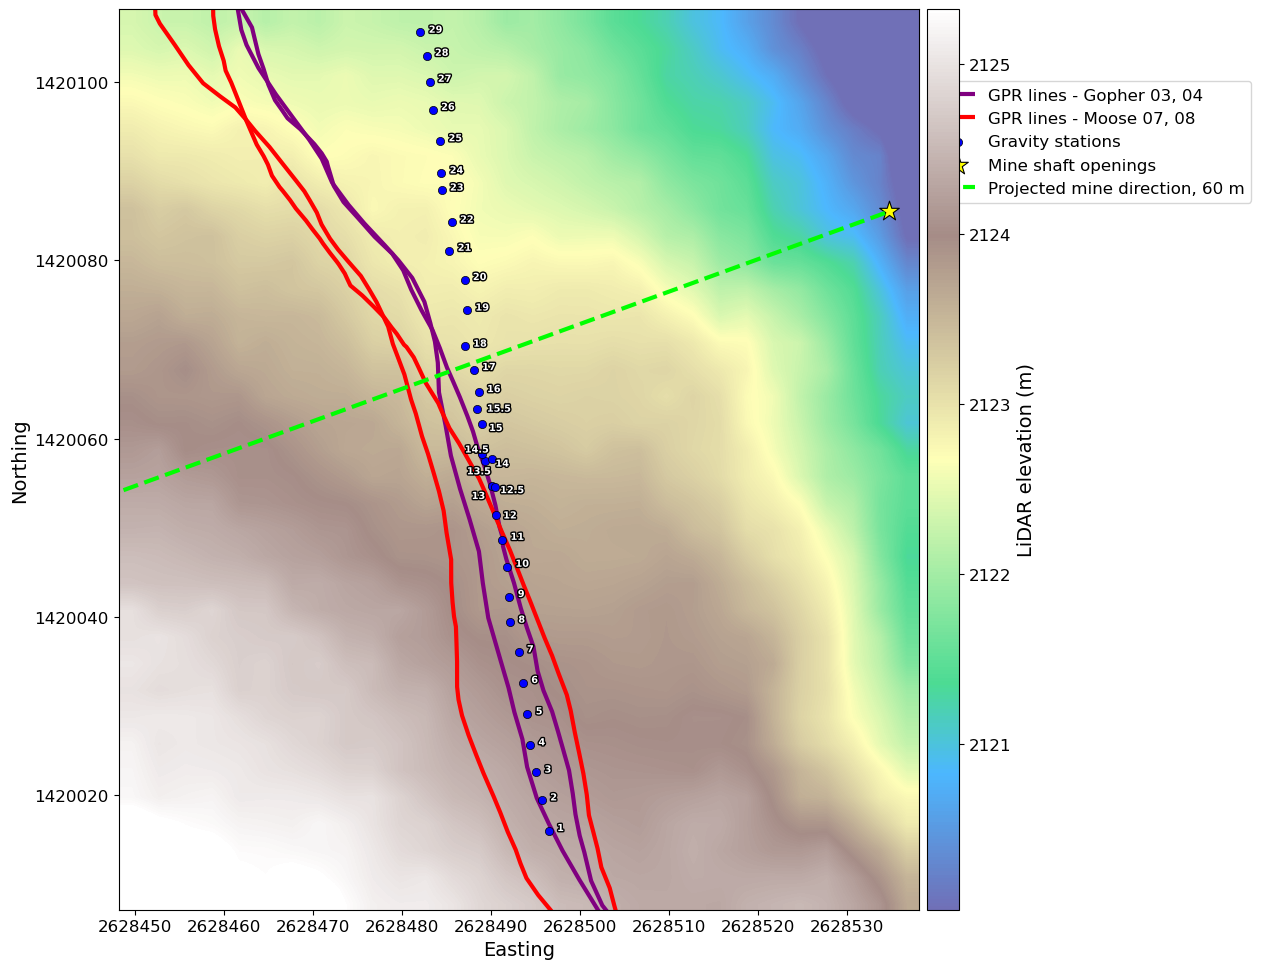

In [19]:
# ============================================================
# Adjustable settings
# ============================================================

figsize = (12, 11)

zoom_vmin = 0.0
zoom_vmax = 3.0

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

gravity_marker_size = 35
poi_marker_size = 220
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8

lidar_alpha = 0.70
lidar_cmap = "terrain"

# LiDAR horizontal CRS is ftUS.
# Elevation values are probably also feet unless metadata says otherwise.
lidar_z_units = "ft"   # use "ft", "in", or "m"

# Manual map padding in meters
pad_west_m  = -30
pad_east_m  = 1
pad_south_m = -10
pad_north_m = -17  # increased north coverage

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")



# ============================================================
# Unit conversions
# ============================================================

ftus_per_m = 1 / 0.304800609601219

pad_west  = pad_west_m  * ftus_per_m
pad_east  = pad_east_m  * ftus_per_m
pad_south = pad_south_m * ftus_per_m
pad_north = pad_north_m * ftus_per_m

mine_projection_length_map_units = mine_projection_length_m * ftus_per_m

z_to_m = {
    "m": 1.0,
    "ft": 0.3048,
    "in": 0.0254
}

if lidar_z_units not in z_to_m:
    raise ValueError("lidar_z_units must be 'm', 'ft', or 'in'.")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)

        if value.is_integer():
            return str(int(value)), int(value)

        return str(value).rstrip("0").rstrip("."), value

    except Exception:
        return str(value), value


# ============================================================
# Load LiDAR files and CRS
# ============================================================

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError(f"No LiDAR .tif files found in: {lidar_folder}")

print("LiDAR files being used:")
for f in lidar_files:
    print(f)

with rasterio.open(lidar_files[0]) as src:
    lidar_crs = src.crs

print("\nPlotting all survey data in LiDAR CRS:")
print(lidar_crs)


# ============================================================
# Reproject survey layers into LiDAR CRS
# ============================================================

gravity_plot = gravity_gdf.to_crs(lidar_crs)
poi_plot = poi_gdf.to_crs(lidar_crs)
gpr_lines_plot = gpr_lines_gdf.to_crs(lidar_crs)
gpr_points_plot = gpr_points_gdf.to_crs(lidar_crs)
anomaly_plot = anomaly_gdf.to_crs(lidar_crs)

selected_gpr_lines_plot = gpr_lines_plot[
    (
        (gpr_lines_plot["gpr_device"] == "Gopher") &
        (gpr_lines_plot["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_plot["gpr_device"] == "Moose") &
        (gpr_lines_plot["line_name"].str.endswith(("0007", "0008")))
    )
].copy()


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_plot,
    ["station_num", "station", "Name"],
    "Could not find gravity station column. Check gravity_plot.columns."
)

elevation_col = find_col(
    gravity_plot,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column. Check gravity_plot.columns."
)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_plot.columns."
)


# ============================================================
# Prep gravity station numbers
# ============================================================

gravity_plot = gravity_plot.copy()

gravity_plot["station_num_clean"] = pd.to_numeric(
    gravity_plot[gravity_station_col],
    errors="coerce"
)


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_map_units * np.sin(azimuth_rad)
dy = mine_projection_length_map_units * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_plot.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_plot.crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_plot[["geometry"]],
    poi_plot[["geometry"]],
    selected_gpr_lines_plot[["geometry"]],
    anomaly_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - pad_west, xmax + pad_east)
ax.set_ylim(ymin - pad_south, ymax + pad_north)

plot_xmin, plot_xmax = ax.get_xlim()
plot_ymin, plot_ymax = ax.get_ylim()


# ============================================================
# Load and plot LiDAR elevation basemap
# ============================================================

srcs = [rasterio.open(fp) for fp in lidar_files]

try:
    lidar_mosaic, lidar_transform = merge(
        srcs,
        bounds=(plot_xmin, plot_ymin, plot_xmax, plot_ymax)
    )
finally:
    for src in srcs:
        src.close()

lidar_elev = lidar_mosaic[0].astype(float)

# Replace raster nodata values with NaN
lidar_elev[lidar_elev <= -9999] = np.nan

# Convert LiDAR elevation values to meters
lidar_elev_m = lidar_elev * z_to_m[lidar_z_units]
lidar_elev_m[~np.isfinite(lidar_elev_m)] = np.nan

if np.all(np.isnan(lidar_elev_m)):
    raise ValueError(
        "LiDAR crop is empty. The plotted survey data and LiDAR tiles still do not overlap."
    )

lidar_vmin = np.nanpercentile(lidar_elev_m, 2)
lidar_vmax = np.nanpercentile(lidar_elev_m, 98)

left, bottom, right, top = array_bounds(
    lidar_elev_m.shape[0],
    lidar_elev_m.shape[1],
    lidar_transform
)

elev_img = ax.imshow(
    lidar_elev_m,
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=lidar_cmap,
    interpolation="bilinear",
    alpha=lidar_alpha,
    vmin=lidar_vmin,
    vmax=lidar_vmax,
    zorder=0
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations
# ============================================================

gravity_plot.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)


# ============================================================
# Plot mine shaft openings
# ============================================================

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ============================================================
# Colorbar
# ============================================================

divider = make_axes_locatable(ax)

cax_elev = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

cbar_elev = fig.colorbar(elev_img, cax=cax_elev)
cbar_elev.set_label("LiDAR elevation (m)")



# ============================================================
# Label gravity stations
# ============================================================

for _, row in gravity_plot.iterrows():
    display_label, lookup_label = clean_label(row[gravity_station_col])

    x_offset, y_offset, ha, va = gravity_label_offsets.get(
        lookup_label,
        default_gravity_label_offset
    )

    ax.annotate(
        display_label,
        xy=(row.geometry.x, row.geometry.y),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=gravity_label_size,
        color="white",
        weight="bold",
        ha=ha,
        va=va,
        zorder=10,
        path_effects=[
            pe.withStroke(linewidth=2, foreground="black")
        ]
    )



# ============================================================
# Final formatting
# ============================================================
# figsize = (14, 11)

# gravity_label_size = 12
# anomaly_label_size = 12
#elevation_label_size = 12
#ax.set_title("Survey Map over Onyx Mine with LiDAR Elevation Basemap")
ax.set_xlabel("Easting")
ax.set_ylabel("Northing")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.18, .90),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.72,
    bottom=0.12,
    top=0.92
)

#plt.savefig("onyx_mine_lidar_basemap_final_without_title.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# Final formatting
# ============================================================

# ax.set_xlabel("Easting", fontsize=14)
# ax.set_ylabel("Northing", fontsize=14)

# ax.tick_params(
#     axis="both",
#     which="major",
#     labelsize=12
# )

# ax.legend(
#     loc="upper left",
#     bbox_to_anchor=(1.02, 0.92),
#     fontsize=12,
#     ncol=1,
#     borderaxespad=0
# )

# cbar_elev.set_label(
#     "LiDAR elevation (m)",
#     fontsize=14
# )

# cbar_elev.ax.tick_params(
#     labelsize=12
# )

# ax.ticklabel_format(style="plain", axis="both", useOffset=False)
# ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.get_xaxis().get_major_formatter().set_scientific(False)
# ax.get_yaxis().get_major_formatter().set_scientific(False)

# plt.xticks(rotation=45)
# #plt.savefig("onyx_mine_lidar_basemap_final_without_title.png", dpi=300, bbox_inches="tight")
# plt.subplots_adjust(
#     left=0.10,
#     right=0.80,   # more room for larger legend
#     bottom=0.12,
#     top=0.95
# )

## Making Final Figure for Presentation

LiDAR files being used:
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26171427.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26201427.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231415.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231418.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231421.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26231424.tif
../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z/LD26261415.tif
../../data/LiDAR/LiDAR_2026-06-

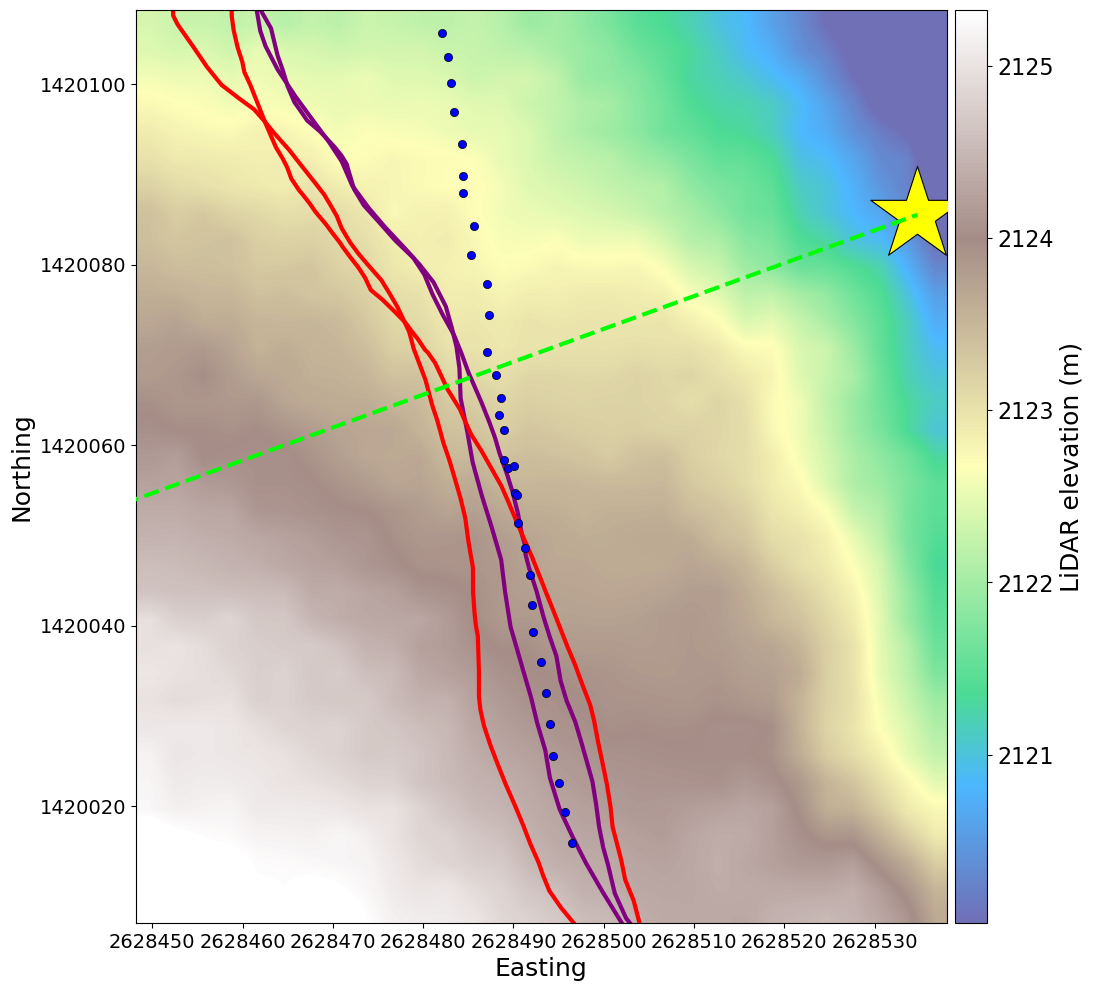

In [29]:
# ============================================================
# Adjustable settings
# ============================================================

figsize = (14, 11)

zoom_vmin = 0.0
zoom_vmax = 3.0

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

gravity_marker_size = 35
poi_marker_size = 5000
anomaly_marker_size = 120

gravity_label_size = 7
anomaly_label_size = 8
elevation_label_size = 8

lidar_alpha = 0.70
lidar_cmap = "terrain"

# LiDAR horizontal CRS is ftUS.
# Elevation values are probably also feet unless metadata says otherwise.
lidar_z_units = "ft"   # use "ft", "in", or "m"

# Manual map padding in meters
pad_west_m  = -30
pad_east_m  = 1
pad_south_m = -10
pad_north_m = -17  # increased north coverage

gravity_label_offsets = {
    15:   (5, -3, "left", "center"),
    15.5: (7, 0, "left", "center"),
    16:   (6, 2, "left", "center"),
    14.5: (5, 3, "right", "center"),
    14:   (17, -2, "right", "center"),
    13.5: (-18, -9, "left", "center"),
    13:   (-5, -7, "right", "center"),
    12.5: (4, -2, "left", "center"),
    12:   (15, 0, "right", "center"),
}

default_gravity_label_offset = (6, 2, "left", "center")



# ============================================================
# Unit conversions
# ============================================================

ftus_per_m = 1 / 0.304800609601219

pad_west  = pad_west_m  * ftus_per_m
pad_east  = pad_east_m  * ftus_per_m
pad_south = pad_south_m * ftus_per_m
pad_north = pad_north_m * ftus_per_m

mine_projection_length_map_units = mine_projection_length_m * ftus_per_m

z_to_m = {
    "m": 1.0,
    "ft": 0.3048,
    "in": 0.0254
}

if lidar_z_units not in z_to_m:
    raise ValueError("lidar_z_units must be 'm', 'ft', or 'in'.")


# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def clean_label(value):
    try:
        value = float(value)

        if value.is_integer():
            return str(int(value)), int(value)

        return str(value).rstrip("0").rstrip("."), value

    except Exception:
        return str(value), value


# ============================================================
# Load LiDAR files and CRS
# ============================================================

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError(f"No LiDAR .tif files found in: {lidar_folder}")

print("LiDAR files being used:")
for f in lidar_files:
    print(f)

with rasterio.open(lidar_files[0]) as src:
    lidar_crs = src.crs

print("\nPlotting all survey data in LiDAR CRS:")
print(lidar_crs)


# ============================================================
# Reproject survey layers into LiDAR CRS
# ============================================================

gravity_plot = gravity_gdf.to_crs(lidar_crs)
poi_plot = poi_gdf.to_crs(lidar_crs)
gpr_lines_plot = gpr_lines_gdf.to_crs(lidar_crs)
gpr_points_plot = gpr_points_gdf.to_crs(lidar_crs)
anomaly_plot = anomaly_gdf.to_crs(lidar_crs)

selected_gpr_lines_plot = gpr_lines_plot[
    (
        (gpr_lines_plot["gpr_device"] == "Gopher") &
        (gpr_lines_plot["line_name"].str.endswith(("0003", "0004")))
    )
    |
    (
        (gpr_lines_plot["gpr_device"] == "Moose") &
        (gpr_lines_plot["line_name"].str.endswith(("0007", "0008")))
    )
].copy()


# ============================================================
# Find needed columns
# ============================================================

gravity_station_col = find_col(
    gravity_plot,
    ["station_num", "station", "Name"],
    "Could not find gravity station column. Check gravity_plot.columns."
)

elevation_col = find_col(
    gravity_plot,
    [
        "elevation_m", "Elevation_m",
        "elevation", "Elevation",
        "elev", "Elev",
        "elevation_ft", "Elevation_ft",
        "altitude", "Altitude",
        "Z", "z"
    ],
    "Could not find elevation column. Check gravity_plot.columns."
)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_plot.columns."
)


# ============================================================
# Prep gravity station numbers
# ============================================================

gravity_plot = gravity_plot.copy()

gravity_plot["station_num_clean"] = pd.to_numeric(
    gravity_plot[gravity_station_col],
    errors="coerce"
)


# ============================================================
# Build projected mine line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_map_units * np.sin(azimuth_rad)
dy = mine_projection_length_map_units * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_plot.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_plot.crs
)


# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    gravity_plot[["geometry"]],
    poi_plot[["geometry"]],
    selected_gpr_lines_plot[["geometry"]],
    anomaly_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds


# ============================================================
# Create figure
# ============================================================

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - pad_west, xmax + pad_east)
ax.set_ylim(ymin - pad_south, ymax + pad_north)

plot_xmin, plot_xmax = ax.get_xlim()
plot_ymin, plot_ymax = ax.get_ylim()


# ============================================================
# Load and plot LiDAR elevation basemap
# ============================================================

srcs = [rasterio.open(fp) for fp in lidar_files]

try:
    lidar_mosaic, lidar_transform = merge(
        srcs,
        bounds=(plot_xmin, plot_ymin, plot_xmax, plot_ymax)
    )
finally:
    for src in srcs:
        src.close()

lidar_elev = lidar_mosaic[0].astype(float)

# Replace raster nodata values with NaN
lidar_elev[lidar_elev <= -9999] = np.nan

# Convert LiDAR elevation values to meters
lidar_elev_m = lidar_elev * z_to_m[lidar_z_units]
lidar_elev_m[~np.isfinite(lidar_elev_m)] = np.nan

if np.all(np.isnan(lidar_elev_m)):
    raise ValueError(
        "LiDAR crop is empty. The plotted survey data and LiDAR tiles still do not overlap."
    )

lidar_vmin = np.nanpercentile(lidar_elev_m, 2)
lidar_vmax = np.nanpercentile(lidar_elev_m, 98)

left, bottom, right, top = array_bounds(
    lidar_elev_m.shape[0],
    lidar_elev_m.shape[1],
    lidar_transform
)

elev_img = ax.imshow(
    lidar_elev_m,
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=lidar_cmap,
    interpolation="bilinear",
    alpha=lidar_alpha,
    vmin=lidar_vmin,
    vmax=lidar_vmax,
    zorder=0
)


# ============================================================
# Plot GPR lines
# ============================================================

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Gopher"].plot(
    ax=ax,
    linewidth=3,
    color="purple",
    label="GPR lines - Gopher 03, 04",
    zorder=2
)

selected_gpr_lines_plot[selected_gpr_lines_plot["gpr_device"] == "Moose"].plot(
    ax=ax,
    linewidth=3,
    color="red",
    label="GPR lines - Moose 07, 08",
    zorder=2
)


# ============================================================
# Plot gravity stations
# ============================================================

gravity_plot.plot(
    ax=ax,
    marker="o",
    markersize=gravity_marker_size,
    color="blue",
    edgecolor="black",
    linewidth=0.5,
    label="Gravity stations",
    zorder=4
)


# ============================================================
# Plot mine shaft openings
# ============================================================

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=5
)


# ============================================================
# Plot projected mine line
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )


# ============================================================
# Colorbar
# ============================================================

divider = make_axes_locatable(ax)

cax_elev = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

cbar_elev = fig.colorbar(elev_img, cax=cax_elev)
cbar_elev.set_label("LiDAR elevation (m)")



# # ============================================================
# # Label gravity stations
# # ============================================================

# for _, row in gravity_plot.iterrows():
#     display_label, lookup_label = clean_label(row[gravity_station_col])

#     x_offset, y_offset, ha, va = gravity_label_offsets.get(
#         lookup_label,
#         default_gravity_label_offset
#     )

#     ax.annotate(
#         display_label,
#         xy=(row.geometry.x, row.geometry.y),
#         xytext=(x_offset, y_offset),
#         textcoords="offset points",
#         fontsize=gravity_label_size,
#         color="white",
#         weight="bold",
#         ha=ha,
#         va=va,
#         zorder=10,
#         path_effects=[
#             pe.withStroke(linewidth=2, foreground="black")
#         ]
#     )



# ============================================================
# Final formatting
# ============================================================

ax.set_xlabel("Easting", fontsize=18)
ax.set_ylabel("Northing", fontsize=18)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=14
)

cbar_elev.set_label(
    "LiDAR elevation (m)",
    fontsize=18
)

cbar_elev.ax.tick_params(
    labelsize=16
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.10,
    right=0.88,
    bottom=0.12,
    top=0.95
)

# Optional save
plt.savefig("../../figures/Final_figures/onyx_mine_lidar_basemap_no_labels_no_legend.png", dpi=300, bbox_inches="tight")

plt.show()


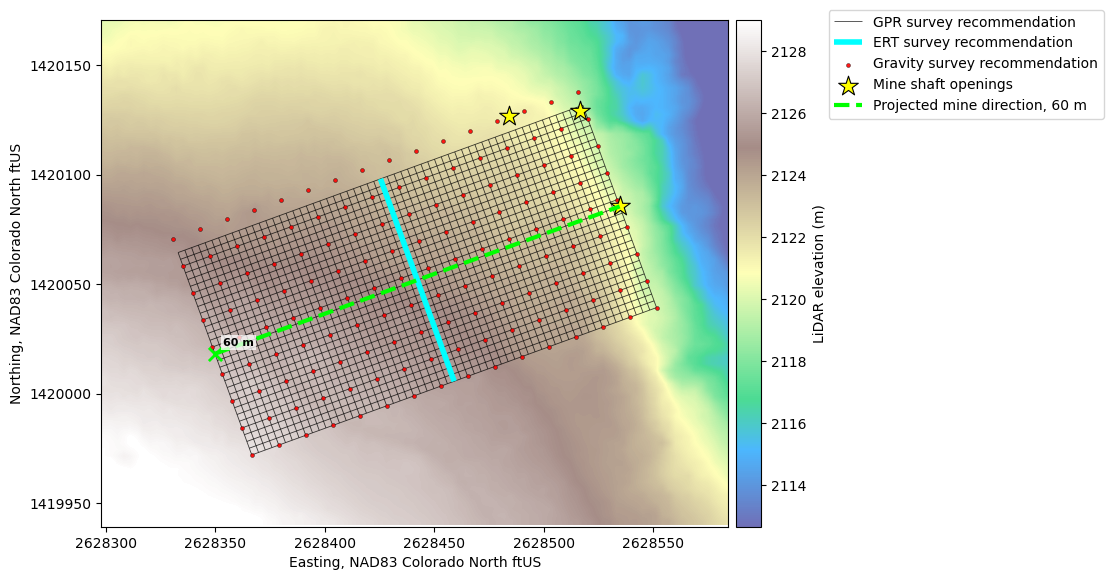

In [16]:
# ============================================================
# Future 60 m x 30 m survey grid recommendation map
# Keeps: LiDAR basemap, mine shaft openings, projected mine direction
# Removes: GPR lines, gravity stations, anomalies
# Adds: 60 m x 30 m rotated grid with 1 m spacing
# ============================================================

figsize = (10, 25)

buffer_m = 10

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

poi_marker_size = 220

lidar_alpha = 0.70
lidar_cmap = "terrain"
lidar_z_units = "ft"

# Grid settings

grid_length_m = 60   # x direction
grid_width_m = 30    # y direction
grid_spacing_m = 1

grid_azimuth_1_deg = 340
grid_azimuth_2_deg = grid_azimuth_1_deg + 90

grid_linewidth = 0.6
grid_alpha = 0.75

# Gravity point-grid settings
gravity_grid_length_m = 60
gravity_grid_width_m = 30
gravity_grid_spacing_m = 4

gravity_grid_length = gravity_grid_length_m * ftus_per_m
gravity_grid_width = gravity_grid_width_m * ftus_per_m
gravity_grid_spacing = gravity_grid_spacing_m * ftus_per_m

# ============================================================
# Unit conversions
# ============================================================

ftus_per_m = 1 / 0.304800609601219

buffer = buffer_m * ftus_per_m
mine_projection_length_map_units = mine_projection_length_m * ftus_per_m

grid_length = grid_length_m * ftus_per_m
grid_width = grid_width_m * ftus_per_m
grid_spacing = grid_spacing_m * ftus_per_m

z_to_m = {
    "m": 1.0,
    "ft": 0.3048,
    "in": 0.0254
}

if lidar_z_units not in z_to_m:
    raise ValueError("lidar_z_units must be 'm', 'ft', or 'in'.")

# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def azimuth_unit_vector(azimuth_deg):
    az = np.deg2rad(azimuth_deg)
    return np.array([np.sin(az), np.cos(az)])


def make_rotated_grid(
    center_point,
    length,
    width,
    spacing,
    azimuth_1_deg,
    azimuth_2_deg,
    crs
):
    center = np.array([center_point.x, center_point.y])

    u = azimuth_unit_vector(azimuth_1_deg)
    v = azimuth_unit_vector(azimuth_2_deg)

    half_length = length / 2
    half_width = width / 2

    width_offsets = np.arange(-half_width, half_width + spacing, spacing)
    length_offsets = np.arange(-half_length, half_length + spacing, spacing)

    grid_lines = []

    # Lines running in the 60 m direction
    for offset in width_offsets:
        p1 = center - half_length * u + offset * v
        p2 = center + half_length * u + offset * v
        grid_lines.append(LineString([p1, p2]))

    # Lines running in the 30 m direction
    for offset in length_offsets:
        p1 = center - half_width * v + offset * u
        p2 = center + half_width * v + offset * u
        grid_lines.append(LineString([p1, p2]))

    return gpd.GeoDataFrame(geometry=grid_lines, crs=crs)

def make_rotated_point_grid(
    center_point,
    length,
    width,
    spacing,
    azimuth_1_deg,
    azimuth_2_deg,
    crs
):
    center = np.array([center_point.x, center_point.y])

    u = azimuth_unit_vector(azimuth_1_deg)
    v = azimuth_unit_vector(azimuth_2_deg)

    half_length = length / 2
    half_width = width / 2

    x_offsets = np.arange(-half_length, half_length + spacing, spacing)
    y_offsets = np.arange(-half_width, half_width + spacing, spacing)

    points = []

    for xoff in x_offsets:
        for yoff in y_offsets:
            p = center + xoff * u + yoff * v
            points.append(Point(p[0], p[1]))

    return gpd.GeoDataFrame(geometry=points, crs=crs)

# ============================================================
# Load LiDAR files and CRS
# ============================================================

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError(f"No LiDAR .tif files found in: {lidar_folder}")

with rasterio.open(lidar_files[0]) as src:
    lidar_crs = src.crs

# ============================================================
# Reproject POI layer into LiDAR CRS
# ============================================================

poi_plot = poi_gdf.to_crs(lidar_crs)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_plot.columns."
)

# ============================================================
# Build projected mine direction line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_map_units * np.sin(azimuth_rad)
dy = mine_projection_length_map_units * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_plot.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_plot.crs
)

# ============================================================
# Build 60 m x 30 m future survey grid
# Centered on projected mine midpoint
# ============================================================

grid_center_point = mine_projection_line.geometry.iloc[0].interpolate(
    0.5,
    normalized=True
)

survey_grid = make_rotated_grid(
    center_point=grid_center_point,
    length=grid_width,        # 60 m along x/grid_azimuth_1_deg
    width=grid_length,          # 30 m along y/perpendicular direction
    spacing=grid_spacing,
    azimuth_1_deg=grid_azimuth_1_deg,
    azimuth_2_deg=grid_azimuth_2_deg,
    crs=poi_plot.crs
)

gravity_grid_points = make_rotated_point_grid(
    center_point=grid_center_point,
    width=gravity_grid_length,     # 60 m wide
    length=gravity_grid_width,       # 30 m tall
    spacing=gravity_grid_spacing,   # 2 m spacing
    azimuth_1_deg=grid_azimuth_1_deg,
    azimuth_2_deg=grid_azimuth_2_deg,
    crs=poi_plot.crs
)

# ============================================================
# Add ERT recommended line
# Uses one of the farthest east GPR grid lines
# ============================================================

# Pick GPR grid lines that run along the long grid direction
gpr_lines_long = survey_grid.iloc[:len(np.arange(-grid_width / 2, grid_width / 2 + grid_spacing, grid_spacing))].copy()

# Find the farthest east line using centroid x-coordinate
east_line_idx = gpr_lines_long.geometry.centroid.x.idxmax()

ert_recommended_line = gpd.GeoDataFrame(
    {
        "label": ["ERT survey recommendation"],
        "geometry": [gpr_lines_long.loc[east_line_idx, "geometry"]]
    },
    crs=survey_grid.crs
)

# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    poi_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
    survey_grid[["geometry"]],
    gravity_grid_points[["geometry"]],
    ert_recommended_line[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

plot_xmin, plot_xmax = ax.get_xlim()
plot_ymin, plot_ymax = ax.get_ylim()

# ============================================================
# Load and plot LiDAR elevation basemap
# ============================================================

srcs = [rasterio.open(fp) for fp in lidar_files]

try:
    lidar_mosaic, lidar_transform = merge(
        srcs,
        bounds=(plot_xmin, plot_ymin, plot_xmax, plot_ymax),
        masked=True
    )
finally:
    for src in srcs:
        src.close()

lidar_elev = lidar_mosaic[0].astype(float)
lidar_elev = np.ma.filled(lidar_elev, np.nan)

lidar_elev_m = lidar_elev * z_to_m[lidar_z_units]
lidar_elev_m[~np.isfinite(lidar_elev_m)] = np.nan

if np.all(np.isnan(lidar_elev_m)):
    raise ValueError(
        "LiDAR crop is empty. The plotted survey data and LiDAR tiles do not overlap."
    )

lidar_vmin = np.nanpercentile(lidar_elev_m, 2)
lidar_vmax = np.nanpercentile(lidar_elev_m, 98)

left, bottom, right, top = array_bounds(
    lidar_elev_m.shape[0],
    lidar_elev_m.shape[1],
    lidar_transform
)

elev_img = ax.imshow(
    lidar_elev_m,
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=lidar_cmap,
    interpolation="bilinear",
    alpha=lidar_alpha,
    vmin=lidar_vmin,
    vmax=lidar_vmax,
    zorder=0
)

# ============================================================
# Plot future survey grid
# ============================================================

survey_grid.plot(
    ax=ax,
    color="black",
    linewidth=grid_linewidth,
    alpha=grid_alpha,
    label="GPR survey recommendation",
    zorder=4
)

ert_recommended_line.plot(
    ax=ax,
    color="cyan",
    linewidth=4,
    linestyle="-",
    label="ERT survey recommendation",
    zorder=7
)

gravity_grid_points.plot(
    ax=ax,
    marker="o",
    markersize=8,
    color="red",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9,
    label="Gravity survey recommendation",
    zorder=5
)

# ============================================================
# Plot mine shaft openings
# ============================================================

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=6
)

# ============================================================
# Plot projected mine direction
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )

# ============================================================
# Colorbar and formatting
# ============================================================

divider = make_axes_locatable(ax)

cax_elev = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

cbar_elev = fig.colorbar(elev_img, cax=cax_elev)
cbar_elev.set_label("LiDAR elevation (m)")

#ax.set_title("Recommended Future 60 m x 30 m Survey Grid near Onyx Mine")
ax.set_xlabel("Easting, NAD83 Colorado North ftUS")
ax.set_ylabel("Northing, NAD83 Colorado North ftUS")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.16, 1.02),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.76,
    bottom=0.12,
    top=0.92
)

#plt.savefig("future_survey_grid_recommendation.png", dpi=300, bbox_inches="tight")
plt.show()

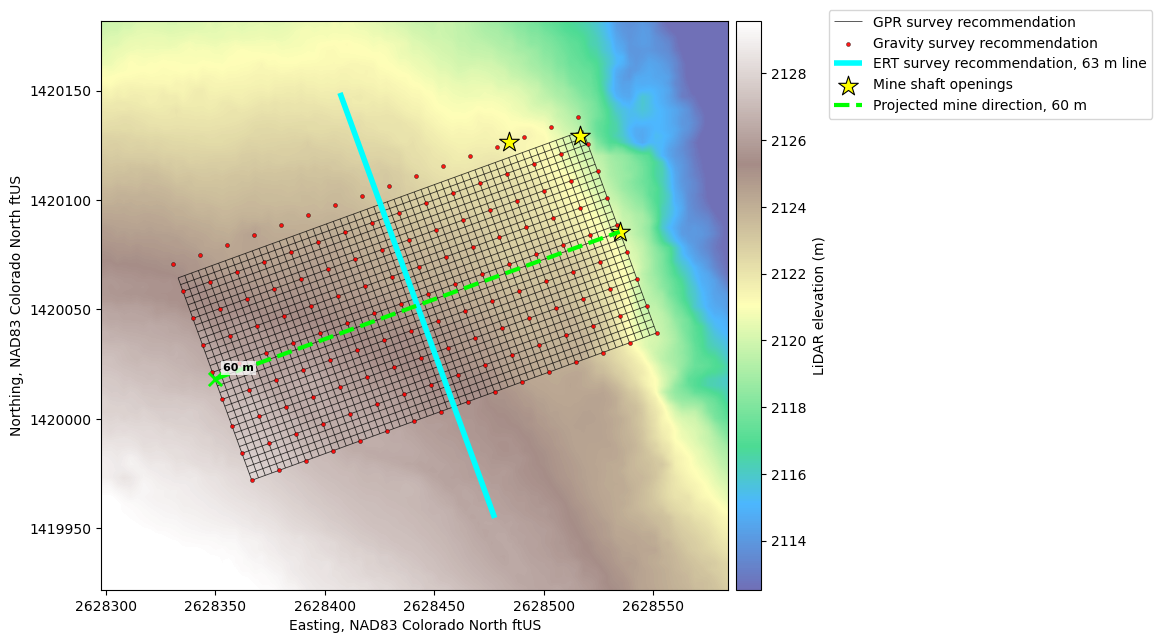

In [18]:
# ============================================================
# Future survey recommendation map
# Adds:
#   - GPR grid
#   - Gravity point grid
#   - ERT recommended 63 m line centered on grid
#   - Mine shaft openings
#   - Projected mine direction
# ============================================================

figsize = (10, 25)
buffer_m = 10

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

poi_marker_size = 220

lidar_alpha = 0.70
lidar_cmap = "terrain"
lidar_z_units = "ft"

# GPR grid settings
grid_length_m = 60
grid_width_m = 30
grid_spacing_m = 1

grid_azimuth_1_deg = 340
grid_azimuth_2_deg = grid_azimuth_1_deg + 90

grid_linewidth = 0.6
grid_alpha = 0.75

# Gravity grid settings
gravity_grid_length_m = 60
gravity_grid_width_m = 30
gravity_grid_spacing_m = 4

# ERT settings
ert_length_m = 63

# ============================================================
# Unit conversions
# ============================================================

ftus_per_m = 1 / 0.304800609601219

buffer = buffer_m * ftus_per_m
mine_projection_length_map_units = mine_projection_length_m * ftus_per_m

grid_length = grid_length_m * ftus_per_m
grid_width = grid_width_m * ftus_per_m
grid_spacing = grid_spacing_m * ftus_per_m

gravity_grid_length = gravity_grid_length_m * ftus_per_m
gravity_grid_width = gravity_grid_width_m * ftus_per_m
gravity_grid_spacing = gravity_grid_spacing_m * ftus_per_m

ert_length = ert_length_m * ftus_per_m

z_to_m = {
    "m": 1.0,
    "ft": 0.3048,
    "in": 0.0254
}

if lidar_z_units not in z_to_m:
    raise ValueError("lidar_z_units must be 'm', 'ft', or 'in'.")

# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def azimuth_unit_vector(azimuth_deg):
    az = np.deg2rad(azimuth_deg)
    return np.array([np.sin(az), np.cos(az)])


def make_rotated_grid(
    center_point,
    length,
    width,
    spacing,
    azimuth_1_deg,
    azimuth_2_deg,
    crs
):
    center = np.array([center_point.x, center_point.y])

    u = azimuth_unit_vector(azimuth_1_deg)
    v = azimuth_unit_vector(azimuth_2_deg)

    half_length = length / 2
    half_width = width / 2

    width_offsets = np.arange(-half_width, half_width + spacing, spacing)
    length_offsets = np.arange(-half_length, half_length + spacing, spacing)

    grid_lines = []

    for offset in width_offsets:
        p1 = center - half_length * u + offset * v
        p2 = center + half_length * u + offset * v
        grid_lines.append(LineString([p1, p2]))

    for offset in length_offsets:
        p1 = center - half_width * v + offset * u
        p2 = center + half_width * v + offset * u
        grid_lines.append(LineString([p1, p2]))

    return gpd.GeoDataFrame(geometry=grid_lines, crs=crs)


def make_rotated_point_grid(
    center_point,
    length,
    width,
    spacing,
    azimuth_1_deg,
    azimuth_2_deg,
    crs
):
    center = np.array([center_point.x, center_point.y])

    u = azimuth_unit_vector(azimuth_1_deg)
    v = azimuth_unit_vector(azimuth_2_deg)

    half_length = length / 2
    half_width = width / 2

    x_offsets = np.arange(-half_length, half_length + spacing, spacing)
    y_offsets = np.arange(-half_width, half_width + spacing, spacing)

    points = []

    for xoff in x_offsets:
        for yoff in y_offsets:
            p = center + xoff * u + yoff * v
            points.append(Point(p[0], p[1]))

    return gpd.GeoDataFrame(geometry=points, crs=crs)

# ============================================================
# Load LiDAR files and CRS
# ============================================================

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError(f"No LiDAR .tif files found in: {lidar_folder}")

with rasterio.open(lidar_files[0]) as src:
    lidar_crs = src.crs

# ============================================================
# Reproject POI layer into LiDAR CRS
# ============================================================

poi_plot = poi_gdf.to_crs(lidar_crs)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_plot.columns."
)

# ============================================================
# Build projected mine direction line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_map_units * np.sin(azimuth_rad)
dy = mine_projection_length_map_units * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_plot.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_plot.crs
)

# ============================================================
# Build survey grids
# ============================================================

grid_center_point = mine_projection_line.geometry.iloc[0].interpolate(
    0.5,
    normalized=True
)

survey_grid = make_rotated_grid(
    center_point=grid_center_point,
    length=grid_width,
    width=grid_length,
    spacing=grid_spacing,
    azimuth_1_deg=grid_azimuth_1_deg,
    azimuth_2_deg=grid_azimuth_2_deg,
    crs=poi_plot.crs
)

gravity_grid_points = make_rotated_point_grid(
    center_point=grid_center_point,
    length=gravity_grid_width,
    width=gravity_grid_length,
    spacing=gravity_grid_spacing,
    azimuth_1_deg=grid_azimuth_1_deg,
    azimuth_2_deg=grid_azimuth_2_deg,
    crs=poi_plot.crs
)

# ============================================================
# Add ERT recommended line
# Centered on the survey grid
# 64 electrodes with 1 m spacing = 63 m spread
# ============================================================

ert_center = grid_center_point
u = azimuth_unit_vector(grid_azimuth_1_deg)

ert_p1 = np.array([ert_center.x, ert_center.y]) - (ert_length / 2) * u
ert_p2 = np.array([ert_center.x, ert_center.y]) + (ert_length / 2) * u

ert_recommended_line = gpd.GeoDataFrame(
    {
        "label": ["ERT survey recommendation"],
        "geometry": [LineString([ert_p1, ert_p2])]
    },
    crs=survey_grid.crs
)

# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    poi_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
    survey_grid[["geometry"]],
    gravity_grid_points[["geometry"]],
    ert_recommended_line[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

plot_xmin, plot_xmax = ax.get_xlim()
plot_ymin, plot_ymax = ax.get_ylim()

# ============================================================
# Load and plot LiDAR elevation basemap
# ============================================================

srcs = [rasterio.open(fp) for fp in lidar_files]

try:
    lidar_mosaic, lidar_transform = merge(
        srcs,
        bounds=(plot_xmin, plot_ymin, plot_xmax, plot_ymax),
        masked=True
    )
finally:
    for src in srcs:
        src.close()

lidar_elev = lidar_mosaic[0].astype(float)
lidar_elev = np.ma.filled(lidar_elev, np.nan)

lidar_elev_m = lidar_elev * z_to_m[lidar_z_units]
lidar_elev_m[~np.isfinite(lidar_elev_m)] = np.nan

if np.all(np.isnan(lidar_elev_m)):
    raise ValueError(
        "LiDAR crop is empty. The plotted survey data and LiDAR tiles do not overlap."
    )

lidar_vmin = np.nanpercentile(lidar_elev_m, 2)
lidar_vmax = np.nanpercentile(lidar_elev_m, 98)

left, bottom, right, top = array_bounds(
    lidar_elev_m.shape[0],
    lidar_elev_m.shape[1],
    lidar_transform
)

elev_img = ax.imshow(
    lidar_elev_m,
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=lidar_cmap,
    interpolation="bilinear",
    alpha=lidar_alpha,
    vmin=lidar_vmin,
    vmax=lidar_vmax,
    zorder=0
)

# ============================================================
# Plot survey recommendations
# ============================================================

survey_grid.plot(
    ax=ax,
    color="black",
    linewidth=grid_linewidth,
    alpha=grid_alpha,
    label="GPR survey recommendation",
    zorder=4
)

gravity_grid_points.plot(
    ax=ax,
    marker="o",
    markersize=8,
    color="red",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9,
    label="Gravity survey recommendation",
    zorder=5
)

ert_recommended_line.plot(
    ax=ax,
    color="cyan",
    linewidth=4,
    linestyle="-",
    label="ERT survey recommendation, 63 m line",
    zorder=7
)

# ============================================================
# Plot mine shaft openings
# ============================================================

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=6
)

# ============================================================
# Plot projected mine direction
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )

# ============================================================
# Colorbar and formatting
# ============================================================

divider = make_axes_locatable(ax)

cax_elev = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

cbar_elev = fig.colorbar(elev_img, cax=cax_elev)
cbar_elev.set_label("LiDAR elevation (m)")

ax.set_xlabel("Easting, NAD83 Colorado North ftUS")
ax.set_ylabel("Northing, NAD83 Colorado North ftUS")

ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.16, 1.02),
    ncol=1,
    borderaxespad=0
)

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.76,
    bottom=0.12,
    top=0.92
)

plt.savefig("future_survey_grid_recommendation.png", dpi=300, bbox_inches="tight")
plt.show()

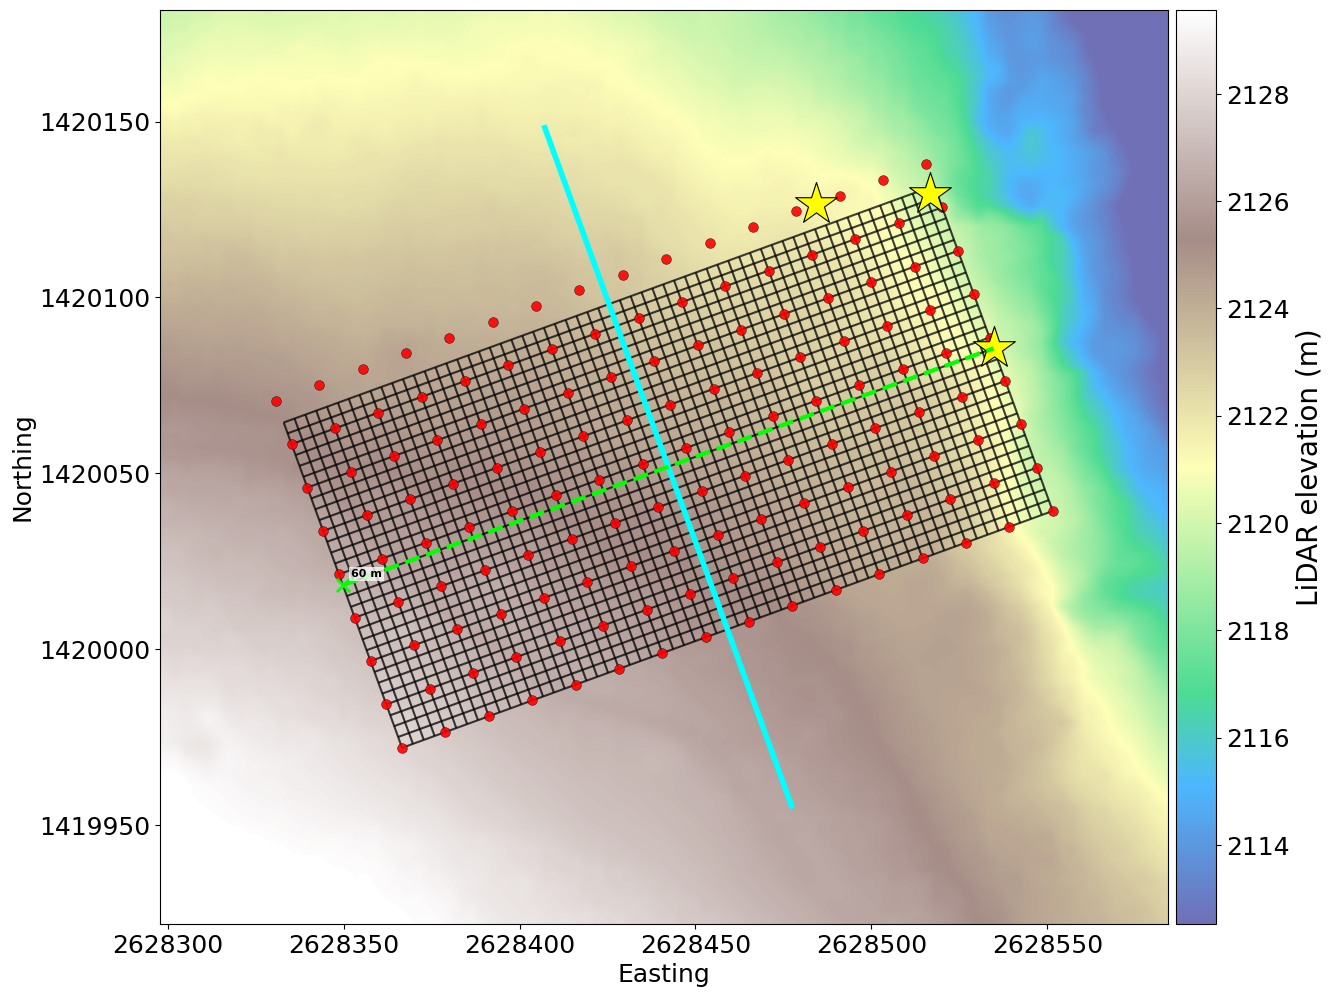

In [37]:
# ============================================================
# Future survey recommendation map
# Adds:
#   - GPR grid
#   - Gravity point grid
#   - ERT recommended 63 m line centered on grid
#   - Mine shaft openings
#   - Projected mine direction
# ============================================================

figsize = (16, 18)
buffer_m = 10

mine_start_name = "above big entrance to mine"
mine_projection_length_m = 60
mine_projection_azimuth_deg = 250

poi_marker_size = 1000

lidar_alpha = 0.70
lidar_cmap = "terrain"
lidar_z_units = "ft"

# GPR grid settings
grid_length_m = 60
grid_width_m = 30
grid_spacing_m = 1

grid_azimuth_1_deg = 340
grid_azimuth_2_deg = grid_azimuth_1_deg + 90

grid_linewidth = 1.5
grid_alpha = 0.75

# Gravity grid settings
gravity_grid_length_m = 60
gravity_grid_width_m = 30
gravity_grid_spacing_m = 4

# ERT settings
ert_length_m = 63

# ============================================================
# Unit conversions
# ============================================================

ftus_per_m = 1 / 0.304800609601219

buffer = buffer_m * ftus_per_m
mine_projection_length_map_units = mine_projection_length_m * ftus_per_m

grid_length = grid_length_m * ftus_per_m
grid_width = grid_width_m * ftus_per_m
grid_spacing = grid_spacing_m * ftus_per_m

gravity_grid_length = gravity_grid_length_m * ftus_per_m
gravity_grid_width = gravity_grid_width_m * ftus_per_m
gravity_grid_spacing = gravity_grid_spacing_m * ftus_per_m

ert_length = ert_length_m * ftus_per_m

z_to_m = {
    "m": 1.0,
    "ft": 0.3048,
    "in": 0.0254
}

if lidar_z_units not in z_to_m:
    raise ValueError("lidar_z_units must be 'm', 'ft', or 'in'.")

# ============================================================
# Helper functions
# ============================================================

def find_col(gdf, possible_cols, error_message):
    for col in possible_cols:
        if col in gdf.columns:
            return col
    raise ValueError(error_message)


def azimuth_unit_vector(azimuth_deg):
    az = np.deg2rad(azimuth_deg)
    return np.array([np.sin(az), np.cos(az)])


def make_rotated_grid(
    center_point,
    length,
    width,
    spacing,
    azimuth_1_deg,
    azimuth_2_deg,
    crs
):
    center = np.array([center_point.x, center_point.y])

    u = azimuth_unit_vector(azimuth_1_deg)
    v = azimuth_unit_vector(azimuth_2_deg)

    half_length = length / 2
    half_width = width / 2

    width_offsets = np.arange(-half_width, half_width + spacing, spacing)
    length_offsets = np.arange(-half_length, half_length + spacing, spacing)

    grid_lines = []

    for offset in width_offsets:
        p1 = center - half_length * u + offset * v
        p2 = center + half_length * u + offset * v
        grid_lines.append(LineString([p1, p2]))

    for offset in length_offsets:
        p1 = center - half_width * v + offset * u
        p2 = center + half_width * v + offset * u
        grid_lines.append(LineString([p1, p2]))

    return gpd.GeoDataFrame(geometry=grid_lines, crs=crs)


def make_rotated_point_grid(
    center_point,
    length,
    width,
    spacing,
    azimuth_1_deg,
    azimuth_2_deg,
    crs
):
    center = np.array([center_point.x, center_point.y])

    u = azimuth_unit_vector(azimuth_1_deg)
    v = azimuth_unit_vector(azimuth_2_deg)

    half_length = length / 2
    half_width = width / 2

    x_offsets = np.arange(-half_length, half_length + spacing, spacing)
    y_offsets = np.arange(-half_width, half_width + spacing, spacing)

    points = []

    for xoff in x_offsets:
        for yoff in y_offsets:
            p = center + xoff * u + yoff * v
            points.append(Point(p[0], p[1]))

    return gpd.GeoDataFrame(geometry=points, crs=crs)

# ============================================================
# Load LiDAR files and CRS
# ============================================================

lidar_folder = Path("../../data/LiDAR/LiDAR_2026-06-05T19_40_33.076Z")
lidar_files = sorted(lidar_folder.glob("*.tif"))

if len(lidar_files) == 0:
    raise FileNotFoundError(f"No LiDAR .tif files found in: {lidar_folder}")

with rasterio.open(lidar_files[0]) as src:
    lidar_crs = src.crs

# ============================================================
# Reproject POI layer into LiDAR CRS
# ============================================================

poi_plot = poi_gdf.to_crs(lidar_crs)

poi_name_col = find_col(
    poi_plot,
    ["point_name", "Name", "name"],
    "Could not find POI name column. Check poi_plot.columns."
)

# ============================================================
# Build projected mine direction line
# ============================================================

mine_start = poi_plot[
    poi_plot[poi_name_col]
    .astype(str)
    .str.lower()
    .str.contains(mine_start_name.lower(), na=False)
].copy()

if mine_start.empty:
    raise ValueError(
        f"Could not find POI containing '{mine_start_name}'. "
        f"Available POI names are:\n{poi_plot[poi_name_col].tolist()}"
    )

mine_start_point = mine_start.geometry.iloc[0]

azimuth_rad = np.deg2rad(mine_projection_azimuth_deg)

dx = mine_projection_length_map_units * np.sin(azimuth_rad)
dy = mine_projection_length_map_units * np.cos(azimuth_rad)

mine_end_point = Point(
    mine_start_point.x + dx,
    mine_start_point.y + dy
)

mine_projection_line = gpd.GeoDataFrame(
    {
        "label": ["Projected mine direction"],
        "geometry": [LineString([mine_start_point, mine_end_point])]
    },
    crs=poi_plot.crs
)

mine_projection_endpoint = gpd.GeoDataFrame(
    {
        "label": [f"{mine_projection_length_m} m"],
        "geometry": [mine_end_point]
    },
    crs=poi_plot.crs
)

# ============================================================
# Build survey grids
# ============================================================

grid_center_point = mine_projection_line.geometry.iloc[0].interpolate(
    0.5,
    normalized=True
)

survey_grid = make_rotated_grid(
    center_point=grid_center_point,
    length=grid_width,
    width=grid_length,
    spacing=grid_spacing,
    azimuth_1_deg=grid_azimuth_1_deg,
    azimuth_2_deg=grid_azimuth_2_deg,
    crs=poi_plot.crs
)

gravity_grid_points = make_rotated_point_grid(
    center_point=grid_center_point,
    length=gravity_grid_width,
    width=gravity_grid_length,
    spacing=gravity_grid_spacing,
    azimuth_1_deg=grid_azimuth_1_deg,
    azimuth_2_deg=grid_azimuth_2_deg,
    crs=poi_plot.crs
)

# ============================================================
# Add ERT recommended line
# Centered on the survey grid
# 64 electrodes with 1 m spacing = 63 m spread
# ============================================================

ert_center = grid_center_point
u = azimuth_unit_vector(grid_azimuth_1_deg)

ert_p1 = np.array([ert_center.x, ert_center.y]) - (ert_length / 2) * u
ert_p2 = np.array([ert_center.x, ert_center.y]) + (ert_length / 2) * u

ert_recommended_line = gpd.GeoDataFrame(
    {
        "label": ["ERT survey recommendation"],
        "geometry": [LineString([ert_p1, ert_p2])]
    },
    crs=survey_grid.crs
)

# ============================================================
# Set map extent
# ============================================================

all_layers = pd.concat([
    poi_plot[["geometry"]],
    mine_projection_line[["geometry"]],
    mine_projection_endpoint[["geometry"]],
    survey_grid[["geometry"]],
    gravity_grid_points[["geometry"]],
    ert_recommended_line[["geometry"]],
])

xmin, ymin, xmax, ymax = all_layers.total_bounds

fig, ax = plt.subplots(figsize=figsize)

ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)

plot_xmin, plot_xmax = ax.get_xlim()
plot_ymin, plot_ymax = ax.get_ylim()

# ============================================================
# Load and plot LiDAR elevation basemap
# ============================================================

srcs = [rasterio.open(fp) for fp in lidar_files]

try:
    lidar_mosaic, lidar_transform = merge(
        srcs,
        bounds=(plot_xmin, plot_ymin, plot_xmax, plot_ymax)
    )
finally:
    for src in srcs:
        src.close()

lidar_elev = lidar_mosaic[0].astype(float)

# Replace raster nodata values with NaN
lidar_elev[lidar_elev <= -9999] = np.nan


lidar_elev_m = lidar_elev * z_to_m[lidar_z_units]
lidar_elev_m[~np.isfinite(lidar_elev_m)] = np.nan

if np.all(np.isnan(lidar_elev_m)):
    raise ValueError(
        "LiDAR crop is empty. The plotted survey data and LiDAR tiles do not overlap."
    )

lidar_vmin = np.nanpercentile(lidar_elev_m, 2)
lidar_vmax = np.nanpercentile(lidar_elev_m, 98)

left, bottom, right, top = array_bounds(
    lidar_elev_m.shape[0],
    lidar_elev_m.shape[1],
    lidar_transform
)

elev_img = ax.imshow(
    lidar_elev_m,
    extent=[left, right, bottom, top],
    origin="upper",
    cmap=lidar_cmap,
    interpolation="bilinear",
    alpha=lidar_alpha,
    vmin=lidar_vmin,
    vmax=lidar_vmax,
    zorder=0
)

# ============================================================
# Plot survey recommendations
# ============================================================

survey_grid.plot(
    ax=ax,
    color="black",
    linewidth=grid_linewidth,
    alpha=grid_alpha,
    label="GPR survey recommendation",
    zorder=4
)

gravity_grid_points.plot(
    ax=ax,
    marker="o",
    markersize=50,
    color="red",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.9,
    label="Gravity survey recommendation",
    zorder=5
)

ert_recommended_line.plot(
    ax=ax,
    color="cyan",
    linewidth=4,
    linestyle="-",
    label="ERT survey recommendation, 63 m line",
    zorder=7
)

# ============================================================
# Plot mine shaft openings
# ============================================================

poi_plot.plot(
    ax=ax,
    marker="*",
    markersize=poi_marker_size,
    color="yellow",
    edgecolor="black",
    linewidth=0.8,
    label="Mine shaft openings",
    zorder=6
)

# ============================================================
# Plot projected mine direction
# ============================================================

mine_projection_line.plot(
    ax=ax,
    color="lime",
    linewidth=3,
    linestyle="--",
    label="Projected mine direction, 60 m",
    zorder=8
)

mine_projection_endpoint.plot(
    ax=ax,
    marker="x",
    markersize=90,
    color="lime",
    linewidth=2,
    zorder=9
)

for _, row in mine_projection_endpoint.iterrows():
    ax.annotate(
        text=f"{mine_projection_length_m} m",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
        color="black",
        fontweight="bold",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.75,
            pad=1.5
        ),
        zorder=10
    )

# ============================================================
# Colorbar and formatting
# ============================================================

divider = make_axes_locatable(ax)

cax_elev = divider.append_axes(
    "right",
    size="4%",
    pad=0.08
)

cbar_elev = fig.colorbar(elev_img, cax=cax_elev)


# Axis tick numbers
ax.tick_params(
    axis="both",
    which="major",
    labelsize=18
)

# Colorbar label
cbar_elev.set_label(
    "LiDAR elevation (m)",
    fontsize=20
)

# Colorbar tick numbers
cbar_elev.ax.tick_params(
    labelsize=18
)

ax.set_xlabel(
    "Easting",
    fontsize=18
)

ax.set_ylabel(
    "Northing",
    fontsize=18
)
# ax.legend(
#     loc="upper left",
#     bbox_to_anchor=(1.16, 1.02),
#     ncol=1,
#     borderaxespad=0
# )

ax.ticklabel_format(style="plain", axis="both", useOffset=False)
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.get_xaxis().get_major_formatter().set_scientific(False)
ax.get_yaxis().get_major_formatter().set_scientific(False)

plt.xticks(rotation=45)

plt.subplots_adjust(
    left=0.1,
    right=0.76,
    bottom=0.12,
    top=0.92
)

plt.savefig("../../figures/Final_figures/future_survey_grid_recommendation_no_labels.png", dpi=300, bbox_inches="tight")
plt.show()